# Importing Libraries 

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
 
from pathlib import Path
from scipy.stats import poisson
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit


import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING) 

In [2]:
base_dir = Path('../artifacts')
PROCESSED_DIR   = base_dir / 'processed_data'
MODEL_DIR       = base_dir / 'models'
FIGURE_DIR      = base_dir / 'figures'
FEATURE_DIR     = base_dir / 'features'
METRICS_DIR     = base_dir / 'metrics'
INTERIM_DIR     = base_dir / 'interim_data'
PREDICTIONS_DIR = base_dir / 'predictions'
 
directories = [PROCESSED_DIR, MODEL_DIR, FIGURE_DIR, FEATURE_DIR,
               METRICS_DIR, INTERIM_DIR, PREDICTIONS_DIR]
 
for path in directories:
    path.mkdir(parents=True, exist_ok=True)
 

# Loading the Data

In [3]:
df = pd.read_csv(f'{PROCESSED_DIR}/xgboost_features.csv', parse_dates=['date'])
print(df.shape)
print(df.dtypes)

(49233, 98)
date                   datetime64[us]
home_team                         str
away_team                         str
home_goals                    float64
away_goals                    float64
                            ...      
away_wc_appearances             int64
home_wc_titles                  int64
away_wc_titles                  int64
home_wc_qf_matches              int64
away_wc_qf_matches              int64
Length: 98, dtype: object


In [4]:
df.head()

,date,home_team,away_team,home_goals,away_goals,home_win,away_win,draw,goal_diff,result,...,home_conf_strength,away_conf_strength,conf_strength_diff,home_tournament_stage,home_wc_appearances,away_wc_appearances,home_wc_titles,away_wc_titles,home_wc_qf_matches,away_wc_qf_matches
0,1872-11-30,Scotland,England,0.0,0.0,0,0,1,0.0,1,...,6,6,0,0,0,0,0,1,0,0
1,1873-03-08,England,Scotland,4.0,2.0,1,0,0,2.0,0,...,6,6,0,0,0,0,1,0,0,0
2,1874-03-07,Scotland,England,2.0,1.0,1,0,0,1.0,0,...,6,6,0,0,0,0,0,1,0,0
3,1875-03-06,England,Scotland,2.0,2.0,0,0,1,0.0,1,...,6,6,0,0,0,0,1,0,0,0
4,1876-03-04,Scotland,England,3.0,0.0,1,0,0,3.0,0,...,6,6,0,0,0,0,0,1,0,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49233 entries, 0 to 49232
Data columns (total 98 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   date                        49233 non-null  datetime64[us]
 1   home_team                   49233 non-null  str           
 2   away_team                   49233 non-null  str           
 3   home_goals                  49233 non-null  float64       
 4   away_goals                  49233 non-null  float64       
 5   home_win                    49233 non-null  int64         
 6   away_win                    49233 non-null  int64         
 7   draw                        49233 non-null  int64         
 8   goal_diff                   49233 non-null  float64       
 9   result                      49233 non-null  int64         
 10  is_competitive              49233 non-null  bool          
 11  home_elo                    49233 non-null  float64       
 12  a

# Feature Columns 

In [6]:
META_COLS   = ['date', 'home_team', 'away_team', 'tournament']
TARGET_COLS = ['home_goals', 'away_goals', 'home_win', 'draw',
               'away_win', 'goal_diff', 'result', 'is_competitive']
 
FEATURE_COLS = [c for c in df.columns if c not in META_COLS + TARGET_COLS]
 
print(f"\nFeatures used : {len(FEATURE_COLS)}")
print(FEATURE_COLS)


Features used : 87
['home_elo', 'away_elo', 'elo_diff', 'home_rank', 'away_rank', 'rank_diff', 'neutral', 'host_advantage', 'home_last3_wins', 'home_last3_draws', 'home_last3_losses', 'home_last3_goals_scored', 'home_last3_goals_conceded', 'away_last3_wins', 'away_last3_draws', 'away_last3_losses', 'away_last3_goals_scored', 'away_last3_goals_conceded', 'diff_last3_goals_scored', 'diff_last3_goals_conceded', 'diff_last3_win_rate', 'home_last5_wins', 'home_last5_draws', 'home_last5_losses', 'home_last5_goals_scored', 'home_last5_goals_conceded', 'home_last5_goal_diff', 'home_last5_ppm', 'home_last5_win_rate', 'home_last5_clean_sheets', 'home_last5_conceded_2plus', 'home_last5_scored_2plus', 'away_last5_wins', 'away_last5_draws', 'away_last5_losses', 'away_last5_goals_scored', 'away_last5_goals_conceded', 'away_last5_goal_diff', 'away_last5_ppm', 'away_last5_win_rate', 'away_last5_clean_sheets', 'away_last5_conceded_2plus', 'away_last5_scored_2plus', 'diff_last5_goals_scored', 'diff_las

# Train / Valid Split 

In [7]:
if 'is_competitive' not in df.columns:
    df['is_competitive'] = True
 
train_df = df[df['is_competitive'] & (df['date'] >= '2000-01-01')].copy()
 
train = train_df[train_df['date'] <  '2024-01-01'].copy()
valid = train_df[train_df['date'] >= '2024-01-01'].copy()
 
print(f"\nTrain : {len(train):,} matches  ({train['date'].dt.year.min()}–{train['date'].dt.year.max()})")
print(f"Valid : {len(valid):,} matches  ({valid['date'].dt.year.min()}–{valid['date'].dt.year.max()})")


Train : 14,855 matches  (2000–2023)
Valid : 1,776 matches  (2024–2026)


In [8]:
X_train = train[FEATURE_COLS].fillna(0)
X_valid = valid[FEATURE_COLS].fillna(0)

y_train_home = train['home_goals'].clip(0, 8)  
y_train_away = train['away_goals'].clip(0, 8)  
y_valid_home = valid['home_goals']             
y_valid_away = valid['away_goals']             

print(f"Train home goals — mean: {y_train_home.mean():.3f}  max: {y_train_home.max()}")
print(f"Train away goals — mean: {y_train_away.mean():.3f}  max: {y_train_away.max()}")

Train home goals — mean: 1.665  max: 8.0
Train away goals — mean: 1.144  max: 8.0


# Sample Weights for Training 

In [9]:
def compute_weights(dates, reference_date, half_life_days=365.0):
    lam      = np.log(2) / half_life_days
    days_ago = (reference_date - dates).dt.days.values
    return np.exp(-lam * days_ago)
 
reference_date = train['date'].max()
sample_weights = compute_weights(train['date'], reference_date, half_life_days=365)
 
print(f"\nSample weight range : {sample_weights.min():.4f} – {sample_weights.max():.4f}")
print(f"Reference date      : {reference_date.date()}")


Sample weight range : 0.0000 – 1.0000
Reference date      : 2023-12-02


# Train XGBoost Models with Optuna 

In [10]:


X_opt_train, X_opt_val, y_opt_train_home, y_opt_val_home = train_test_split(
    X_train, y_train_home, test_size=0.2, random_state=42, shuffle=False
)
_, _, y_opt_train_away, y_opt_val_away = train_test_split(
    X_train, y_train_away, test_size=0.2, random_state=42, shuffle=False
)

opt_weights_train = sample_weights[:len(X_opt_train)]

print(f"Optuna internal train : {len(X_opt_train):,}")
print(f"Optuna internal val   : {len(X_opt_val):,}")

Optuna internal train : 11,884
Optuna internal val   : 2,971


In [11]:
def objective_cv(trial, X, y, weights, n_splits=3):
    params = {
        'objective':            'reg:squarederror',
        'n_estimators':          1000,
        'learning_rate':         trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':             trial.suggest_int('max_depth', 3, 8),
        'min_child_weight':      trial.suggest_int('min_child_weight', 1, 15),
        'subsample':             trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':             trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':            trial.suggest_float('reg_lambda', 0.1, 8.0),
        'early_stopping_rounds': 50,
        'random_state':          42,
        'n_jobs':                -1,
    }
    tscv  = TimeSeriesSplit(n_splits=n_splits)
    maes  = []
    for train_idx, val_idx in tscv.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
        w_tr        = weights[train_idx]
        model = XGBRegressor(**params)
        model.fit(X_tr, y_tr, sample_weight=w_tr,
                  eval_set=[(X_val, y_val)], verbose=False)
        preds = model.predict(X_val).clip(0)
        maes.append(mean_absolute_error(y_val, preds))
    return np.mean(maes)

In [12]:
# ── Tune Home Goals Model ─────────────────────────────────────
print("Tuning home goals model (100 trials, 3-fold CV)...")

study_home = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_home.enqueue_trial({
    'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
})
study_home.optimize(
    lambda trial: objective_cv(trial, X_train, y_train_home, sample_weights),
    n_trials=100, show_progress_bar=True,
)

print(f"\nBest home MAE (3-fold CV) : {study_home.best_value:.4f}")
for k, v in study_home.best_params.items():
    print(f"  {k}: {v}")


# ── Tune Away Goals Model ─────────────────────────────────────
print("\nTuning away goals model (100 trials, 3-fold CV)...")

study_away = optuna.create_study(direction='minimize', sampler=TPESampler(seed=42))
study_away.enqueue_trial({
    'learning_rate': 0.05, 'max_depth': 4, 'min_child_weight': 5,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_alpha': 0.1, 'reg_lambda': 1.0,
})
study_away.optimize(
    lambda trial: objective_cv(trial, X_train, y_train_away, sample_weights),
    n_trials=100, show_progress_bar=True,
)

print(f"\nBest away MAE (3-fold CV) : {study_away.best_value:.4f}")
for k, v in study_away.best_params.items():
    print(f"  {k}: {v}")

Tuning home goals model (100 trials, 3-fold CV)...


  0%|          | 0/100 [00:00<?, ?it/s]


Best home MAE (3-fold CV) : 1.1708
  learning_rate: 0.024916220934600372
  max_depth: 3
  min_child_weight: 1
  subsample: 0.8195852322660473
  colsample_bytree: 0.7146996609136661
  reg_alpha: 0.04424189611905599
  reg_lambda: 2.0597750387505824

Tuning away goals model (100 trials, 3-fold CV)...


  0%|          | 0/100 [00:00<?, ?it/s]


Best away MAE (3-fold CV) : 0.9473
  learning_rate: 0.0745135084760114
  max_depth: 6
  min_child_weight: 1
  subsample: 0.8964837841758087
  colsample_bytree: 0.7320292453562316
  reg_alpha: 0.006167115891316923
  reg_lambda: 3.362803568649848


In [13]:
print("\nTraining final models with best Optuna parameters...")

best_params_home = {
    'objective':            'reg:squarederror',
    'n_estimators':          1000,
    'early_stopping_rounds': 50,
    'random_state':          42,
    'n_jobs':                -1,
    **study_home.best_params,
}

best_params_away = {
    'objective':            'reg:squarederror',
    'n_estimators':          1000,
    'early_stopping_rounds': 50,
    'random_state':          42,
    'n_jobs':                -1,
    **study_away.best_params,
}

model_home = XGBRegressor(**best_params_home)
model_home.fit(
    X_train, y_train_home,
    sample_weight=sample_weights,
    eval_set=[(X_valid, y_valid_home)],   # ← real valid set, used only for early stopping now
    verbose=50,
)

model_away = XGBRegressor(**best_params_away)
model_away.fit(
    X_train, y_train_away,
    sample_weight=sample_weights,
    eval_set=[(X_valid, y_valid_away)],
    verbose=50,
)

print(f"\nFinal home model — best iteration : {model_home.best_iteration}")
print(f"Final away model — best iteration : {model_away.best_iteration}")


Training final models with best Optuna parameters...
[0]	validation_0-rmse:1.56248
[50]	validation_0-rmse:1.36632
[100]	validation_0-rmse:1.33635
[150]	validation_0-rmse:1.32715
[200]	validation_0-rmse:1.32345
[250]	validation_0-rmse:1.32092
[300]	validation_0-rmse:1.31898
[350]	validation_0-rmse:1.31932
[400]	validation_0-rmse:1.31914
[429]	validation_0-rmse:1.31984
[0]	validation_0-rmse:1.30276
[50]	validation_0-rmse:1.14108
[89]	validation_0-rmse:1.14174

Final home model — best iteration : 379
Final away model — best iteration : 39


# Predict on Validation Set 

In [14]:
valid = valid.copy()
valid['pred_home_goals'] = model_home.predict(X_valid)
valid['pred_away_goals'] = model_away.predict(X_valid)
 
# Clip to non-negative (Poisson objective handles this but just in case)
valid['pred_home_goals'] = valid['pred_home_goals'].clip(0)
valid['pred_away_goals'] = valid['pred_away_goals'].clip(0)
 
print("\nSample predictions:")
print(valid[[
    'date', 'home_team', 'away_team',
    'home_goals', 'pred_home_goals',
    'away_goals', 'pred_away_goals'
]].head(10).to_string(index=False))


Sample predictions:
      date            home_team         away_team  home_goals  pred_home_goals  away_goals  pred_away_goals
2024-01-12                Qatar           Lebanon         3.0         2.363497         0.0         0.682837
2024-01-13                China        Tajikistan         0.0         1.626892         0.0         0.963982
2024-01-13            Australia             India         2.0         2.713773         0.0         0.566836
2024-01-13           Uzbekistan             Syria         0.0         2.088556         0.0         0.770157
2024-01-13          Ivory Coast     Guinea-Bissau         2.0         2.988234         0.0         0.663959
2024-01-14              Nigeria Equatorial Guinea         1.0         1.808606         1.0         0.846947
2024-01-14                Japan           Vietnam         4.0         3.971248         2.0         0.399362
2024-01-14                Egypt        Mozambique         2.0         2.650181         2.0         0.475603
2024-01

# Goal Prediction Metrics 

In [15]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))
 
mae_home  = mean_absolute_error(y_valid_home, valid['pred_home_goals'])
mae_away  = mean_absolute_error(y_valid_away, valid['pred_away_goals'])
rmse_home = rmse(y_valid_home, valid['pred_home_goals'])
rmse_away = rmse(y_valid_away, valid['pred_away_goals'])
 
# Baseline: always predict training mean
baseline_home = np.full(len(valid), y_train_home.mean())
baseline_away = np.full(len(valid), y_train_away.mean())
 
print("\n Goal Prediction Metrics ")
print(f"  Home goals  →  MAE: {mae_home:.4f}  |  RMSE: {rmse_home:.4f}")
print(f"  Away goals  →  MAE: {mae_away:.4f}  |  RMSE: {rmse_away:.4f}")
 
print("\n Baseline (always predict training mean) ")
print(f"  Home goals  →  MAE: {mean_absolute_error(y_valid_home, baseline_home):.4f}  |  RMSE: {rmse(y_valid_home, baseline_home):.4f}")
print(f"  Away goals  →  MAE: {mean_absolute_error(y_valid_away, baseline_away):.4f}  |  RMSE: {rmse(y_valid_away, baseline_away):.4f}")
 
print(f"\n  Mean pred home : {valid['pred_home_goals'].mean():.3f}  (actual: {y_valid_home.mean():.3f})")
print(f"  Mean pred away : {valid['pred_away_goals'].mean():.3f}  (actual: {y_valid_away.mean():.3f})")


 Goal Prediction Metrics 
  Home goals  →  MAE: 1.0067  |  RMSE: 1.3185
  Away goals  →  MAE: 0.8616  |  RMSE: 1.1390

 Baseline (always predict training mean) 
  Home goals  →  MAE: 1.2349  |  RMSE: 1.5748
  Away goals  →  MAE: 0.9754  |  RMSE: 1.3235

  Mean pred home : 1.562  (actual: 1.588)
  Mean pred away : 1.124  (actual: 1.158)


# Scatter — Predicted vs Actual Goals

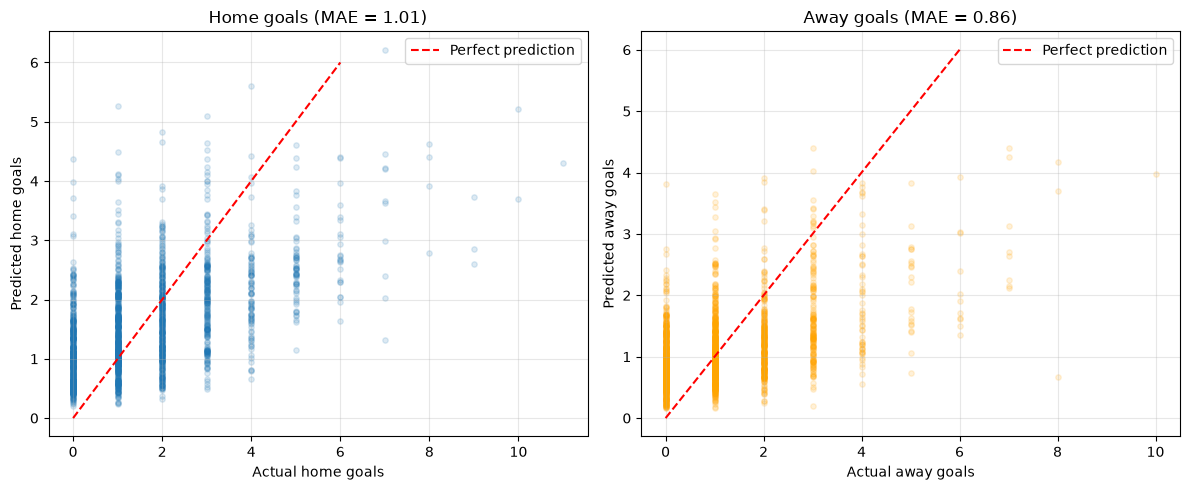

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].scatter(y_valid_home, valid['pred_home_goals'], alpha=0.15, s=15)
axes[0].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual home goals')
axes[0].set_ylabel('Predicted home goals')
axes[0].set_title(f'Home goals (MAE = {mae_home:.2f})')
axes[0].legend()
axes[0].grid(alpha=0.3)
 
axes[1].scatter(y_valid_away, valid['pred_away_goals'], alpha=0.15, s=15, color='orange')
axes[1].plot([0, 6], [0, 6], 'r--', label='Perfect prediction')
axes[1].set_xlabel('Actual away goals')
axes[1].set_ylabel('Predicted away goals')
axes[1].set_title(f'Away goals (MAE = {mae_away:.2f})')
axes[1].legend()
axes[1].grid(alpha=0.3)
 
plt.tight_layout()
plt.show()

# Derive Win/Draw/Loss Probabilities via Score Grid

In [17]:
MAX_GOALS = 10
 
dc_rho  = joblib.load(f'{MODEL_DIR}/dc_rho.pkl')
rho_fit = dc_rho['rho']
print(f"DC rho loaded: {rho_fit:.6f}")


def dc_correction(hg, ag, lambda_h, lambda_a, rho):
    if hg == 0 and ag == 0: return 1 - lambda_h * lambda_a * rho
    if hg == 0 and ag == 1: return 1 + lambda_h * rho
    if hg == 1 and ag == 0: return 1 + lambda_a * rho
    if hg == 1 and ag == 1: return 1 - rho
    return 1.0


def score_grid_probabilities(lambda_home, lambda_away):
    """Score grid with DC correction applied — boosts draw probabilities."""
    score_matrix = np.zeros((MAX_GOALS, MAX_GOALS))
    for hg in range(MAX_GOALS):
        for ag in range(MAX_GOALS):
            p_h = poisson.pmf(hg, lambda_home)
            p_a = poisson.pmf(ag, lambda_away)
            tau = dc_correction(hg, ag, lambda_home, lambda_away, rho_fit)
            score_matrix[hg, ag] = max(p_h * p_a * tau, 0)

    score_matrix /= score_matrix.sum()

    p_home_win = np.tril(score_matrix, k=-1).sum()
    p_draw     = np.trace(score_matrix)
    p_away_win = np.triu(score_matrix, k=1).sum()

    return p_home_win, p_draw, p_away_win
 
 
probs = valid.apply(
    lambda r: score_grid_probabilities(r['pred_home_goals'], r['pred_away_goals']),
    axis=1, result_type='expand'
)
probs.columns = ['prob_home_win', 'prob_draw', 'prob_away_win']
valid = pd.concat([valid, probs], axis=1)

DC rho loaded: -0.094717


# Outcome Evaluation 

In [18]:
def predict_outcome(p_home, p_draw, p_away, draw_threshold=0.28):
    """
    0 = Home Win, 1 = Draw, 2 = Away Win
    If draw probability exceeds threshold → predict draw.
    Otherwise take argmax of home/away.
    """
    if p_draw >= draw_threshold:
        return 1
    return 0 if p_home >= p_away else 2
 
 
def evaluate_outcome(df, draw_threshold=0.28):
    """Full evaluation: accuracy + confusion matrix + classification report."""
    df = df.copy()
    df['pred_result'] = df.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'],
            draw_threshold
        ), axis=1
    )
 
    accuracy = (df['pred_result'] == df['result']).mean()
    print(f"\n Outcome Accuracy (draw_threshold={draw_threshold:.2f}) ")
    print(f"  Correct outcome predicted: {accuracy:.2%}")
 
    cm = confusion_matrix(df['result'], df['pred_result'], labels=[0, 1, 2])
    print("\n Confusion Matrix (rows=actual, cols=predicted)")
    print(pd.DataFrame(
        cm,
        index  =['Actual HW', 'Actual Draw', 'Actual AW'],
        columns=['Pred HW',   'Pred Draw',   'Pred AW']
    ))
 
    print("\n Classification Report ")
    print(classification_report(
        df['result'], df['pred_result'],
        target_names=['HomeWin', 'Draw', 'AwayWin'],
        zero_division=0
    ))
    return df['pred_result'] 
 


In [19]:
print(valid[['prob_home_win', 'prob_draw', 'prob_away_win']].head())

print(valid[['prob_home_win', 'prob_draw', 'prob_away_win']].isna().sum())

       prob_home_win  prob_draw  prob_away_win
46732       0.741843   0.175908       0.082250
46734       0.517796   0.269734       0.212470
46735       0.818342   0.132917       0.048741
46736       0.670704   0.211497       0.117800
46737       0.831716   0.119170       0.049115
prob_home_win    0
prob_draw        0
prob_away_win    0
dtype: int64


In [20]:
 
# Default argmax
print("=" * 60)
print("DEFAULT: argmax ")
print("=" * 60)
 
valid['pred_result'] = valid[['prob_home_win', 'prob_draw', 'prob_away_win']].idxmax(axis=1)
valid['pred_result'] = valid['pred_result'].map({
    'prob_home_win': 0,
    'prob_draw':     1,
    'prob_away_win': 2,
})
 
accuracy = (valid['pred_result'] == valid['result']).mean()
print(f"\n  Correct outcome predicted: {accuracy:.2%}")
 
cm = confusion_matrix(valid['result'], valid['pred_result'], labels=[0, 1, 2])
print("\n Confusion Matrix ")
print(pd.DataFrame(
    cm,
    index  =['Actual HW', 'Actual Draw', 'Actual AW'],
    columns=['Pred HW',   'Pred Draw',   'Pred AW']
))
print("\n Classification Report ")
print(classification_report(
    valid['result'], valid['pred_result'],
    target_names=['HomeWin', 'Draw', 'AwayWin'],
    zero_division=0
))

DEFAULT: argmax 

  Correct outcome predicted: 60.92%

 Confusion Matrix 
             Pred HW  Pred Draw  Pred AW
Actual HW        696          6      123
Actual Draw      248          6      159
Actual AW        153          5      380

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.63      0.84      0.72       825
        Draw       0.35      0.01      0.03       413
     AwayWin       0.57      0.71      0.63       538

    accuracy                           0.61      1776
   macro avg       0.52      0.52      0.46      1776
weighted avg       0.55      0.61      0.53      1776



In [21]:
# Threshold tuning
print("\n" + "=" * 60)
print("TUNING: Find best draw threshold")
print("=" * 60)
 
thresholds = np.arange(0.20, 0.45, 0.01)
results    = []

for thresh in thresholds:
    preds = valid.apply(
        lambda r: predict_outcome(
            r['prob_home_win'], r['prob_draw'], r['prob_away_win'], thresh
        ), axis=1
    )
    acc       = (preds == valid['result']).mean()
    draw_rate = (preds == 1).mean()
    results.append({
        'threshold':      round(thresh, 2),
        'accuracy':       round(acc, 4),
        'pred_draw_rate': round(draw_rate, 4),
    })

df_thresh   = pd.DataFrame(results)
best_row    = df_thresh.loc[df_thresh['accuracy'].idxmax()]
best_thresh = best_row['threshold']
best_acc    = best_row['accuracy']

print(f"Actual draw rate : {(valid['result'] == 1).mean():.2%}")
print(f"Best threshold   : {best_thresh:.2f}")
print(f"Best accuracy    : {best_acc:.2%}")
print(df_thresh.to_string(index=False))


TUNING: Find best draw threshold
Actual draw rate : 23.25%
Best threshold   : 0.33
Best accuracy    : 61.32%
 threshold  accuracy  pred_draw_rate
      0.20    0.4482          0.7005
      0.21    0.4713          0.6599
      0.22    0.4854          0.6278
      0.23    0.4977          0.5991
      0.24    0.5113          0.5631
      0.25    0.5208          0.5315
      0.26    0.5349          0.4882
      0.27    0.5512          0.4206
      0.28    0.5687          0.3542
      0.29    0.5704          0.2872
      0.30    0.5856          0.2145
      0.31    0.5985          0.1475
      0.32    0.6115          0.0907
      0.33    0.6132          0.0417
      0.34    0.6115          0.0180
      0.35    0.6109          0.0073
      0.36    0.6109          0.0028
      0.37    0.6115          0.0006
      0.38    0.6109          0.0000
      0.39    0.6109          0.0000
      0.40    0.6109          0.0000
      0.41    0.6109          0.0000
      0.42    0.6109          0.0000
  

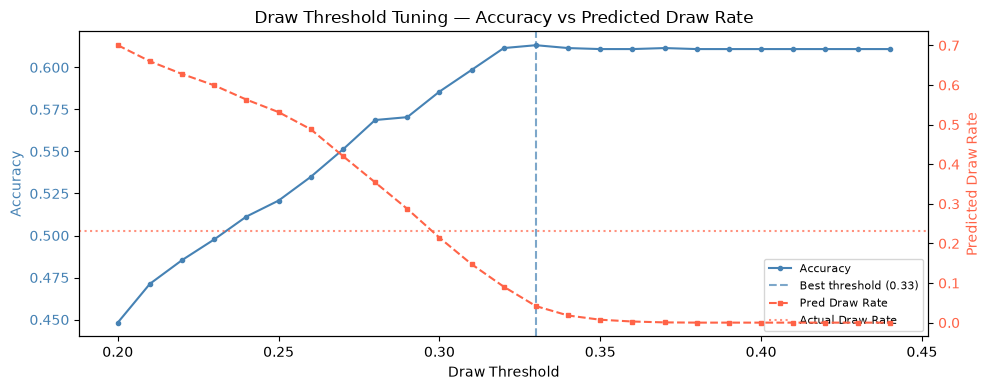

In [22]:
# Threshold tuning plot
fig, ax1 = plt.subplots(figsize=(10, 4))
 
ax1.plot(df_thresh['threshold'], df_thresh['accuracy'],
         color='steelblue', marker='o', markersize=3, label='Accuracy')
ax1.axvline(best_thresh, color='steelblue', linestyle='--', alpha=0.7,
            label=f'Best threshold ({best_thresh:.2f})')
ax1.set_xlabel('Draw Threshold')
ax1.set_ylabel('Accuracy', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
 
ax2 = ax1.twinx()
ax2.plot(df_thresh['threshold'], df_thresh['pred_draw_rate'],
         color='tomato', marker='s', markersize=3, linestyle='--',
         label='Pred Draw Rate')
ax2.axhline((valid['result'] == 1).mean(), color='tomato', linestyle=':',
            alpha=0.7, label='Actual Draw Rate')
ax2.set_ylabel('Predicted Draw Rate', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right', fontsize=8)
 
plt.title('Draw Threshold Tuning — Accuracy vs Predicted Draw Rate')
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/xgb_threshold_tuning.png', dpi=150)
plt.show()

In [23]:
# Final evaluation with best threshold
print("\n" + "=" * 60)
print(f"FINAL EVALUATION — draw_threshold = {best_thresh:.2f}")
print("=" * 60)
 
final_preds = evaluate_outcome(valid, draw_threshold=best_thresh)
valid['pred_result'] = final_preds


FINAL EVALUATION — draw_threshold = 0.33

 Outcome Accuracy (draw_threshold=0.33) 
  Correct outcome predicted: 61.32%

 Confusion Matrix (rows=actual, cols=predicted)
             Pred HW  Pred Draw  Pred AW
Actual HW        687         18      120
Actual Draw      231         30      152
Actual AW        140         26      372

 Classification Report 
              precision    recall  f1-score   support

     HomeWin       0.65      0.83      0.73       825
        Draw       0.41      0.07      0.12       413
     AwayWin       0.58      0.69      0.63       538

    accuracy                           0.61      1776
   macro avg       0.54      0.53      0.49      1776
weighted avg       0.57      0.61      0.56      1776



# Goal Distribution

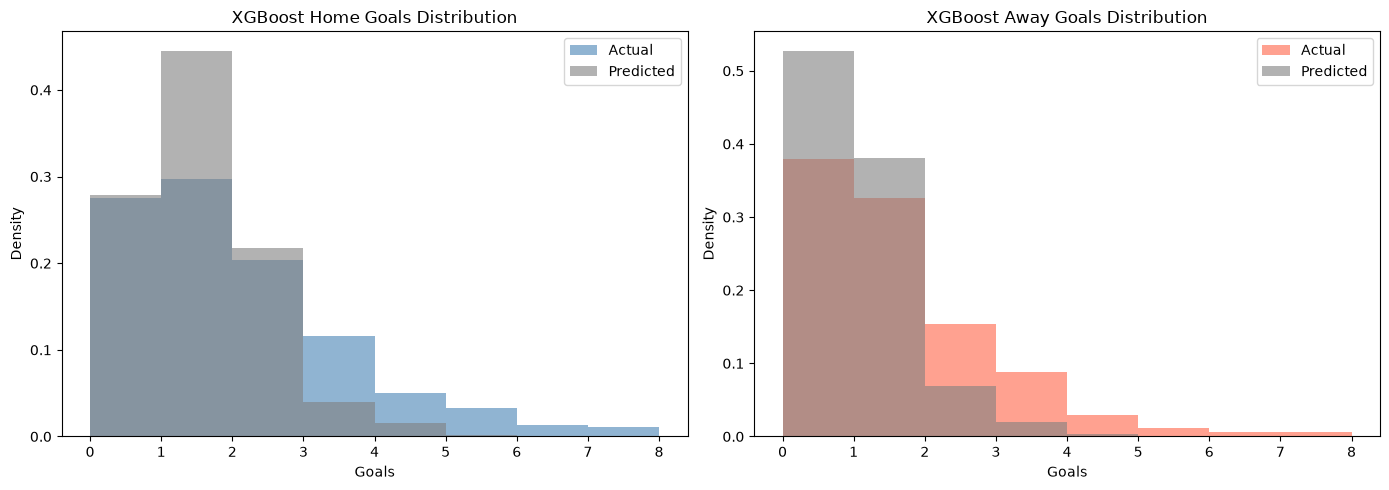

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
for ax, col_actual, col_pred, title, color in [
    (axes[0], 'home_goals', 'pred_home_goals', 'Home Goals', 'steelblue'),
    (axes[1], 'away_goals', 'pred_away_goals', 'Away Goals', 'tomato'),
]:
    ax.hist(valid[col_actual].clip(0, 7), bins=range(9),
            alpha=0.6, label='Actual', color=color, density=True)
    ax.hist(valid[col_pred].clip(0, 7), bins=range(9),
            alpha=0.6, label='Predicted', color='gray', density=True)
    ax.set_title(f'XGBoost {title} Distribution')
    ax.set_xlabel('Goals')
    ax.set_ylabel('Density')
    ax.legend()
 
plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}/xgb_goal_distribution.png', dpi=150)
plt.show()

# Feature Importance


── Top 20 Features — Home Goals Model ───────────────────


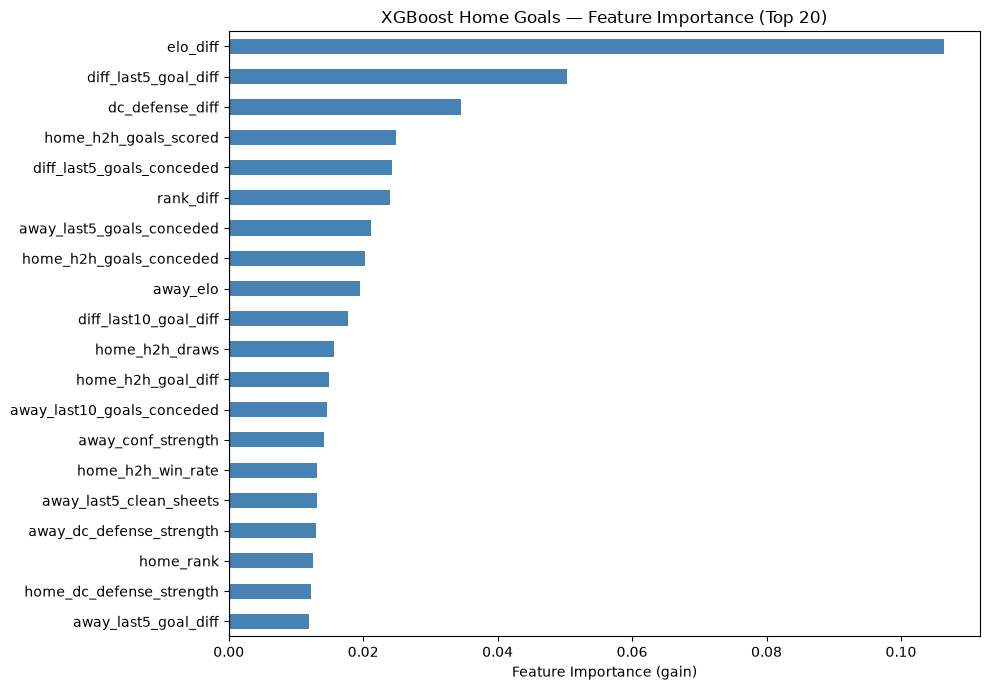

elo_diff                      0.106437
diff_last5_goal_diff          0.050356
dc_defense_diff               0.034588
home_h2h_goals_scored         0.024881
diff_last5_goals_conceded     0.024322
rank_diff                     0.023964
away_last5_goals_conceded     0.021187
home_h2h_goals_conceded       0.020323
away_elo                      0.019518
diff_last10_goal_diff         0.017691
home_h2h_draws                0.015706
home_h2h_goal_diff            0.014845
away_last10_goals_conceded    0.014640
away_conf_strength            0.014107
home_h2h_win_rate             0.013160
away_last5_clean_sheets       0.013143
away_dc_defense_strength      0.012951
home_rank                     0.012607
home_dc_defense_strength      0.012304
away_last5_goal_diff          0.011990

── Top 20 Features — Away Goals Model ───────────────────


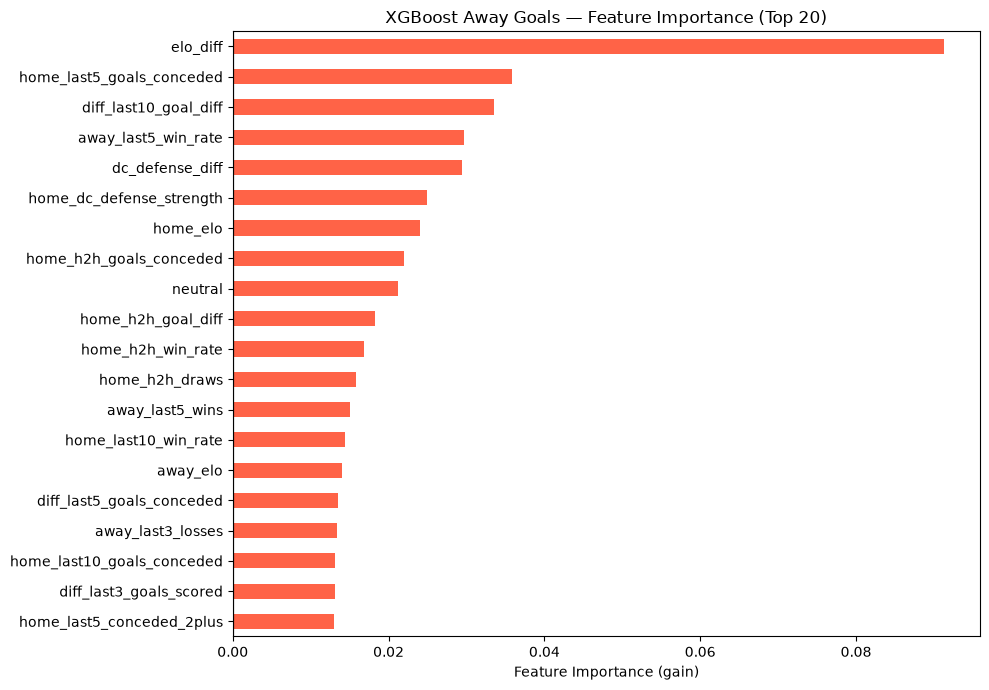

elo_diff                      0.091340
home_last5_goals_conceded     0.035837
diff_last10_goal_diff         0.033564
away_last5_win_rate           0.029738
dc_defense_diff               0.029428
home_dc_defense_strength      0.024994
home_elo                      0.023984
home_h2h_goals_conceded       0.021967
neutral                       0.021275
home_h2h_goal_diff            0.018212
home_h2h_win_rate             0.016828
home_h2h_draws                0.015793
away_last5_wins               0.015026
home_last10_win_rate          0.014446
away_elo                      0.014016
diff_last5_goals_conceded     0.013529
away_last3_losses             0.013439
home_last10_goals_conceded    0.013161
diff_last3_goals_scored       0.013063
home_last5_conceded_2plus     0.012973


In [25]:
def plot_feature_importance(model, feature_cols, title, filename,
                             top_n=20, color='steelblue'):
    importance = pd.Series(
        model.feature_importances_, index=feature_cols
    ).sort_values(ascending=False).head(top_n)
 
    fig, ax = plt.subplots(figsize=(10, 7))
    importance.sort_values().plot(kind='barh', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Feature Importance (gain)')
    ax.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig(f'{FIGURE_DIR}/{filename}', dpi=150)
    plt.show()
 
    return importance
 
 
print("\n── Top 20 Features — Home Goals Model ───────────────────")
imp_home = plot_feature_importance(
    model_home, FEATURE_COLS,
    'XGBoost Home Goals — Feature Importance (Top 20)',
    'xgb_importance_home.png', color='steelblue'
)
print(imp_home.to_string())
 
print("\n── Top 20 Features — Away Goals Model ───────────────────")
imp_away = plot_feature_importance(
    model_away, FEATURE_COLS,
    'XGBoost Away Goals — Feature Importance (Top 20)',
    'xgb_importance_away.png', color='tomato'
)
print(imp_away.to_string())

# Learning Curves

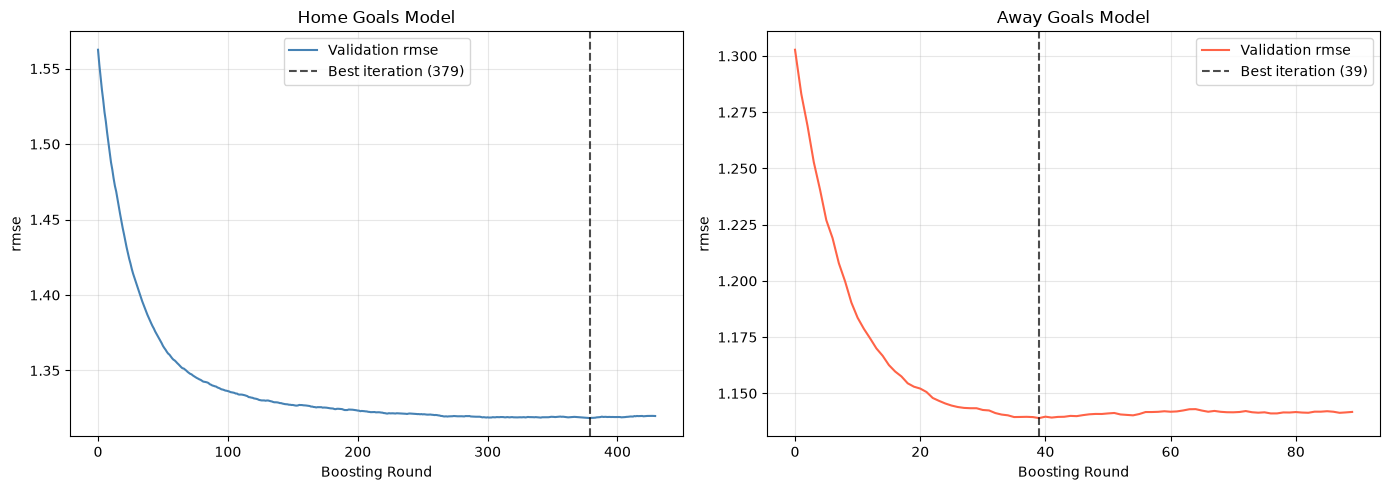

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, model, title, color in [
    (axes[0], model_home, 'Home Goals Model', 'steelblue'),
    (axes[1], model_away, 'Away Goals Model', 'tomato'),
]:

    results = model.evals_result()

    # Get validation dataset name
    eval_set = list(results.keys())[0]

    # Get metric name automatically
    metric = list(results[eval_set].keys())[0]

    values = results[eval_set][metric]

    epochs = len(values)

    ax.plot(
        range(epochs),
        values,
        color=color,
        label=f'Validation {metric}'
    )

    if hasattr(model, "best_iteration"):
        ax.axvline(
            model.best_iteration,
            color='black',
            linestyle='--',
            alpha=0.7,
            label=f'Best iteration ({model.best_iteration})'
        )

    ax.set_xlabel('Boosting Round')
    ax.set_ylabel(metric)
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    f'{FIGURE_DIR}/xgb_learning_curves.png',
    dpi=150,
    bbox_inches="tight"
)

plt.show()
 

# Saving the Model 

In [27]:
 
# Models
joblib.dump(model_home, f'{MODEL_DIR}/xgb_home.pkl')
joblib.dump(model_away, f'{MODEL_DIR}/xgb_away.pkl')
 
# Feature column order — critical for consistent inference
pd.Series(FEATURE_COLS).to_csv(f'{FEATURE_DIR}/xgb_feature_cols.csv', index=False)
 
# Threshold config
thresh_cfg = {
    'draw_threshold':      float(best_thresh),
    'validation_accuracy': float(best_acc),
    'actual_draw_rate':    round((valid['result'] == 1).mean(), 4),
}
with open(f'{METRICS_DIR}/xgb_threshold.json', 'w') as f:
    json.dump(thresh_cfg, f, indent=2)
 
# Feature importance tables
imp_home.to_frame('importance').reset_index().rename(
    columns={'index': 'feature'}
).to_csv(f'{INTERIM_DIR}/xgb_importance_home.csv', index=False)

imp_away.to_frame('importance').reset_index().rename(
    columns={'index': 'feature'}
).to_csv(f'{INTERIM_DIR}/xgb_importance_away.csv', index=False)
 
# Validation predictions
valid_preds = valid[['date', 'home_team', 'away_team',
                      'home_goals', 'away_goals', 'result',
                      'pred_home_goals', 'pred_away_goals',
                      'prob_home_win', 'prob_draw', 'prob_away_win',
                      'pred_result']].copy()
 
valid_preds.to_csv(f'{PREDICTIONS_DIR}/xgb_valid_preds.csv', index=False)
 
print("\nSaved:")
print(f"  models/       → xgb_home.pkl, xgb_away.pkl")
print(f"  features/     → xgb_feature_cols.csv")
print(f"  metrics/      → xgb_threshold.json")
print(f"  interim_data/ → xgb_importance_home.csv, xgb_importance_away.csv")
print(f"  predictions/  → xgb_valid_preds.csv")
print(json.dumps(thresh_cfg, indent=2))


Saved:
  models/       → xgb_home.pkl, xgb_away.pkl
  features/     → xgb_feature_cols.csv
  metrics/      → xgb_threshold.json
  interim_data/ → xgb_importance_home.csv, xgb_importance_away.csv
  predictions/  → xgb_valid_preds.csv
{
  "draw_threshold": 0.33,
  "validation_accuracy": 0.6132,
  "actual_draw_rate": 0.2325
}
